# 과제 1 - SVM 회귀


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [41]:
# 데이터 로드
raw_data = pd.read_csv("http://lib.stat.cmu.edu/datasets/boston", sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_data.values[::2, :], raw_data.values[1::2, :3]])
df = pd.DataFrame(data, columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'target'])

# X와 y 분리
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# 모델 생성
svr = LinearSVR(epsilon = 10)

# 모델 훈련
svr.fit(X_train, y_train)

LinearSVR(epsilon=10)

In [43]:
# 예측
y_pred = svr.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 82.29098242740577
R-squared: -0.12214287714436467


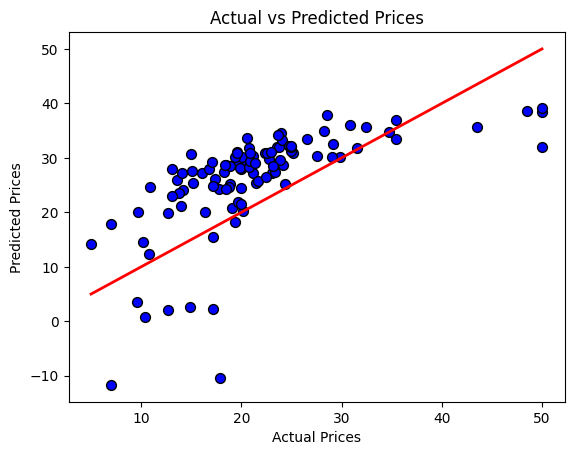

In [44]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

Epsilon: 0.05
Mean Squared Error: 94.70535410618285
R-squared: -0.29142872527300523


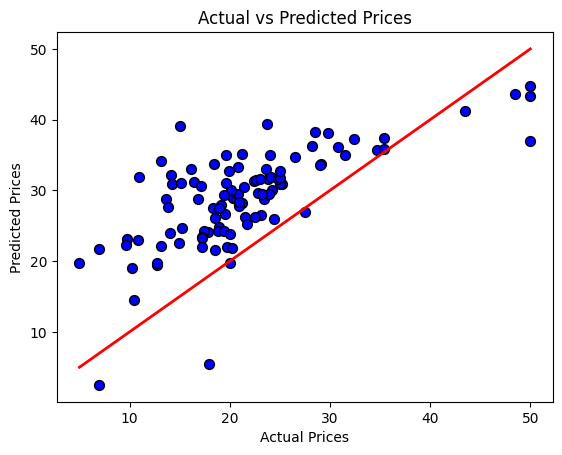

Epsilon: 0.1
Mean Squared Error: 37.935814481477394
R-squared: 0.48269661203020464


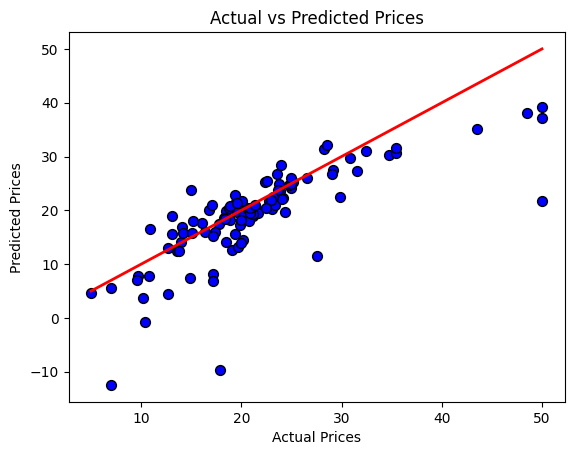

Epsilon: 1
Mean Squared Error: 33.610196981755834
R-squared: 0.5416819433919435


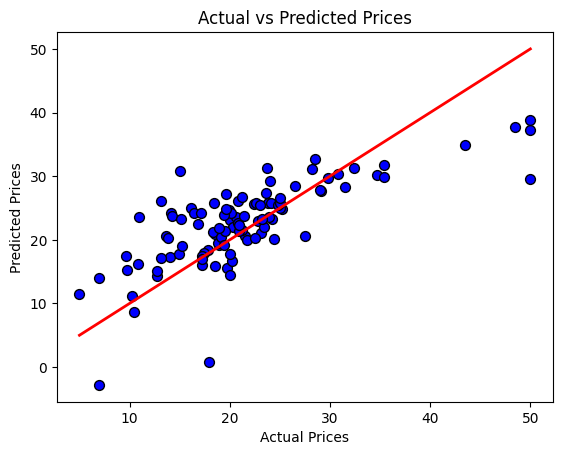

Epsilon: 5
Mean Squared Error: 44.7792381482509
R-squared: 0.3893777708105671


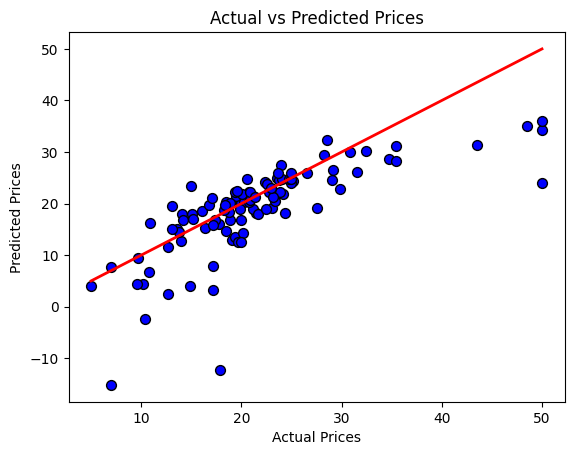

Epsilon: 10
Mean Squared Error: 53.37337383681993
R-squared: 0.27218573027748216


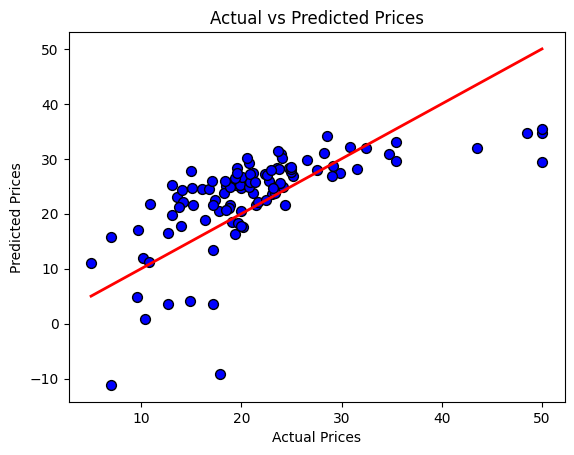

In [51]:
mse_list = []
r2_list = []

for epsilon in [0.05, 0.1, 1, 5, 10]:
    # 모델 생성
    svr = LinearSVR(epsilon = epsilon)

    # 모델 훈련
    svr.fit(X_train, y_train)

    # 예측
    y_pred = svr.predict(X_test)

    # 성능 평가
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
    r2 = r2_score(y_test, y_pred)
    r2_list.append(r2)
    print("Epsilon:", epsilon)
    print("Mean Squared Error:", mse)
    print("R-squared:", r2)

    plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title('Actual vs Predicted Prices')
    plt.show()

results_df = pd.DataFrame({
    'Epsilon': [0.05, 0.1, 1, 5, 10],
    'Mean Squared Error': mse_list,
    'R-squared': r2_list
})

In [52]:
results_df

,Epsilon,Mean Squared Error,R-squared
0,0.05,94.705354,-0.291429
1,0.10,37.935814,0.482697
2,1.00,33.610197,0.541682
3,5.00,44.779238,0.389378
4,10.00,53.373374,0.272186


* Epsilon이 0.05이거나 10일 때, MSE의 값이 커짐을 볼 수 있다. 이는 epsilon 값이 너무 작거나 큰 경우 모델이 데이터를 제대로 학습하지 못함을 의미한다.
* Epsilon이 1일 때, R-squared가 0.542로 가장 높으며 모델이 데이터를 가장 잘 설명함을 알 수 있다. 또한, Epsilon이 1인 경우 MSE도 33.6으로 가장 작다. 그래프를 봤을 때도 대부분의 점들이 빨간 선에 분포되어 있음을 볼 수 있다.
* 따라서 이 데이터에서는 Epsion 1이 가장 적절하다.



# 과제 1-2 : SVM 분류

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [55]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

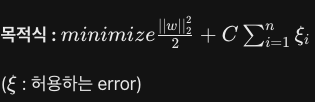


In [57]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.01, 0.1, 1, 5, 10, 50]
train_accuracies = []
test_accuracies = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.1:
Training Accuracy: 0.9666666666666667
Testing Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------

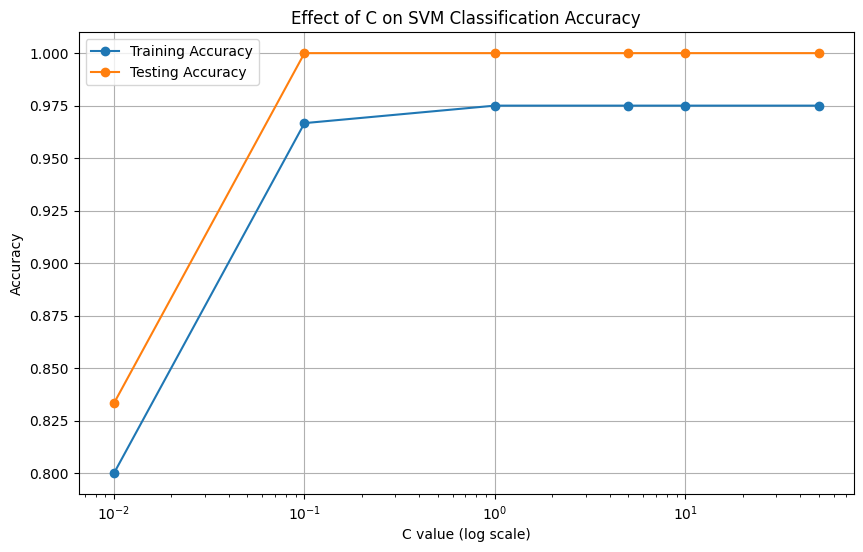

In [58]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()
